# Phase 2: Data Preprocessing

## Objectives

- Handle missing values
- Remove duplicates
- Handle outliers
- Encode categorical variables
- Scale numerical features
- Handle skewed distributions
- Perform feature engineering
- Feature selection

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
#Load Dataset
df = pd.read_csv("/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Dataset Shape
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 1460
Columns : 81


In [5]:
# Missing Values
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
# Missing Value Percentage
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent = missing_percent[missing_percent>0].sort_values(ascending=False)
missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [7]:
# Drop Columns Having More Than 50% Missing Values
missing_cols = missing_percent[missing_percent>50].index
df.drop(columns=missing_cols,inplace=True)

print(df.shape)

(1460, 76)


In [8]:
# Numerical and Categorical Columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical :",len(num_cols))
print("Categorical :",len(cat_cols))

Numerical : 38
Categorical : 38


In [10]:
# Missing  numeric Values
missing = df.select_dtypes(include=np.number).isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

In [13]:
# Missing  categorical  Values
missing = df.select_dtypes(include="object").isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing

FireplaceQu     690
GarageQual       81
GarageFinish     81
GarageCond       81
GarageType       81
BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
Electrical        1
dtype: int64

In [14]:
# Fill Remaining Missing Values

num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
print(df.isnull().sum().sum())

0


In [16]:
# Duplicate Rows
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [17]:
# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

print(df.shape)

(1460, 76)


In [18]:
# Encode Categorical Variables
le = LabelEncoder()


for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [19]:
# Feature and Target
X = df.drop("SalePrice",axis=1)
y = df["SalePrice"]

In [20]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
# Numerical Features
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenP

In [23]:
# Skewness of Numerical Features
skewness = df[num_cols].skew().sort_values(ascending=False)
skewness

Utilities     38.209946
MiscVal       24.476794
PoolArea      14.828374
Condition2    13.171844
LotArea       12.207688
                ...    
SaleType      -3.868638
Functional    -4.084958
GarageQual    -4.587825
GarageCond    -5.455517
Street       -15.518770
Length: 76, dtype: float64

In [24]:
# Highly Skewed Features
high_skew = skewness[abs(skewness) > 0.75]
high_skew

Utilities        38.209946
MiscVal          24.476794
PoolArea         14.828374
Condition2       13.171844
LotArea          12.207688
3SsnPorch        10.304342
Heating           9.855100
LowQualFinSF      9.011341
RoofMatl          8.109402
LandSlope         4.813682
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
Condition1        3.019196
MasVnrArea        2.677616
LotFrontage       2.409147
OpenPorchSF       2.364342
BldgType          2.245648
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
RoofStyle         1.473796
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
GarageType        0.853020
2ndFlrSF          0.813030
FireplaceQu       0.791903
LotConfig        -1.135632
BsmtExposure     -1.189376
BsmtQual         -1.344288
KitchenQual      -1.422808
MSZoning         -1.735395
E

In [25]:
# Log Transformation
for col in high_skew.index:
    if col != "SalePrice":
        df[col] = np.log1p(df[col])

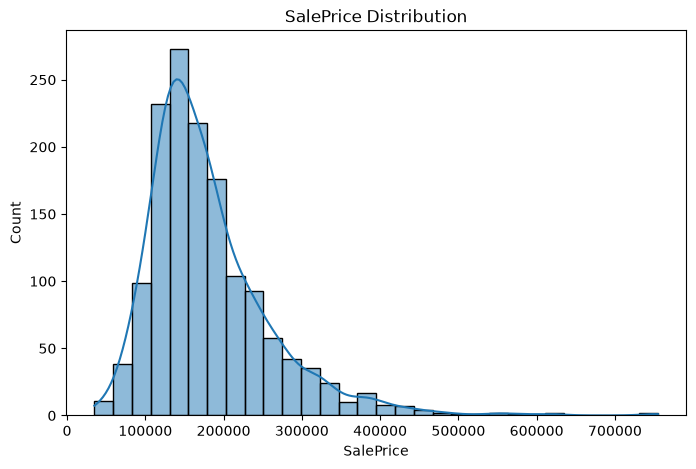

In [26]:
# SalePrice Distribution Before Transformation
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"],kde=True,bins=30)
plt.title("SalePrice Distribution")
plt.show()

In [27]:
# Skewness After Transformation
df[num_cols].skew().sort_values(ascending=False)

Utilities      38.209946
PoolArea       14.363102
3SsnPorch       7.734975
Heating         7.717634
RoofMatl        7.548284
                 ...    
GarageQual     -4.966907
TotalBsmtSF    -5.154670
Functional     -5.426651
GarageCond     -5.899243
Street        -15.518770
Length: 76, dtype: float64

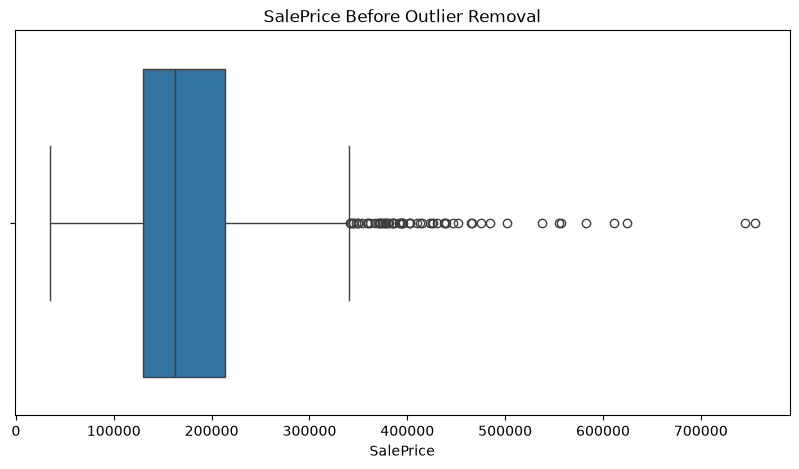

In [28]:
# Boxplot Before Outlier Treatment
plt.figure(figsize=(10,5))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice Before Outlier Removal")
plt.show()

In [29]:
# IQR Calculation
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

In [30]:
# Remove Outliers
df = df[
    (df["SalePrice"] >= Q1 - 1.5*IQR) &
    (df["SalePrice"] <= Q3 + 1.5*IQR)
]

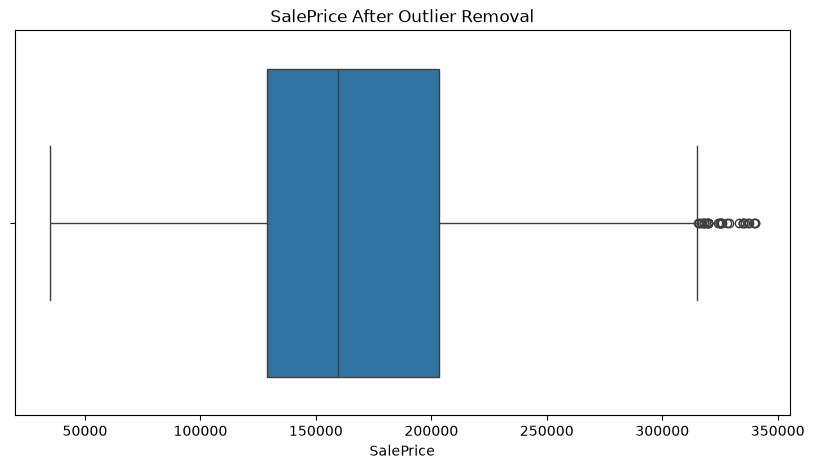

In [31]:
# Boxplot After Outlier Removal
plt.figure(figsize=(10,5))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice After Outlier Removal")
plt.show()

In [32]:
# 1 Feature Engineering - House Age
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

In [33]:
# 2 Feature Engineering - Total Bathrooms2
df["TotalBathrooms"] = (
    df["FullBath"] +
    0.5*df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5*df["BsmtHalfBath"]
)

In [34]:
# 3 Feature Engineering - Total Square Feet3
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

In [35]:
# 4 Feature Engineering - Total Porch Area
df["TotalPorchArea"] = (
    df["OpenPorchSF"] +
    df["EnclosedPorch"] +
    df["3SsnPorch"] +
    df["ScreenPorch"]
)

In [36]:
# 5 Feature Engineering - Remodeled House
df["RemodeledHouse"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

In [67]:
# Check Newly Created Features
df[["HouseAge","TotalBathrooms","TotalSF","TotalPorchArea","RemodeledHouse"]].head()

,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,5,3.500000,15.552676,4.127134,0
1,31,2.263295,9.238188,0.000000,0
2,7,3.500000,15.647882,3.761200,1
3,91,2.000000,15.530382,5.472023,1
4,8,3.500000,16.089311,4.442651,0


In [68]:
# Correlation with SalePrice
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr

SalePrice         1.000000
OverallQual       0.769415
GrLivArea         0.679333
TotalBathrooms    0.624218
GarageCars        0.617408
                    ...   
BsmtQual         -0.415588
ExterQual        -0.415793
GarageType       -0.500374
GarageFinish     -0.562976
HouseAge         -0.566459
Name: SalePrice, Length: 81, dtype: float64

In [69]:
# Top 20 Important Features
corr.head(20)

SalePrice         1.000000
OverallQual       0.769415
GrLivArea         0.679333
TotalBathrooms    0.624218
GarageCars        0.617408
GarageArea        0.587398
FullBath          0.579846
YearBuilt         0.565397
YearRemodAdd      0.535928
1stFlrSF          0.525171
GarageYrBlt       0.468422
TotRmsAbvGrd      0.465085
OpenPorchSF       0.455452
Fireplaces        0.443886
TotalPorchArea    0.417863
Foundation        0.394449
LotArea           0.352253
MasVnrArea        0.350672
CentralAir        0.306161
WoodDeckSF        0.301881
Name: SalePrice, dtype: float64

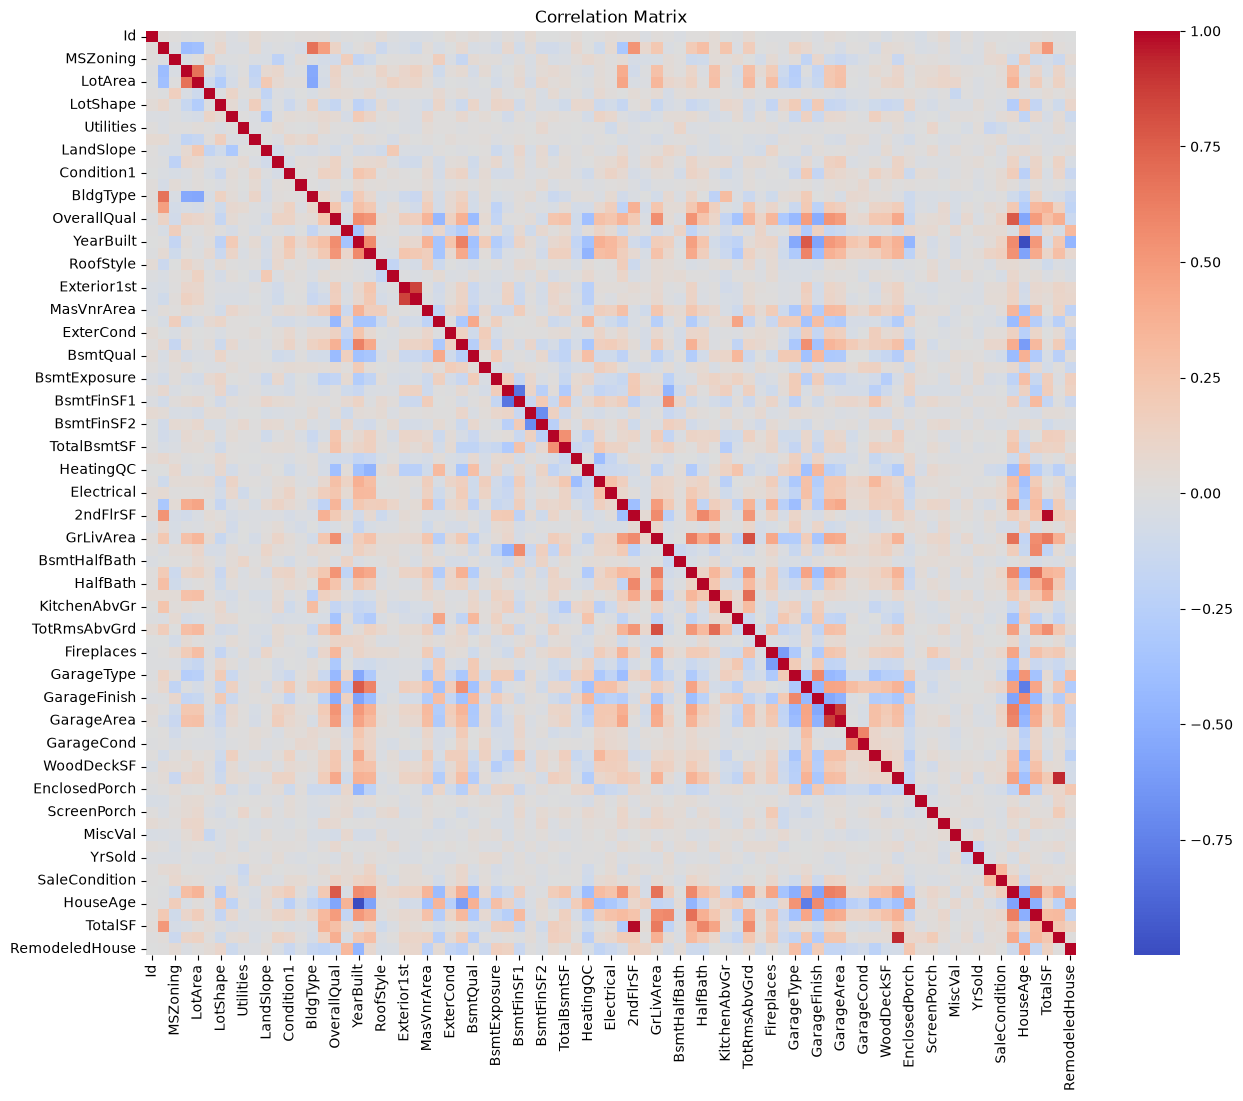

In [70]:
# Correlation Heatmap
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [71]:
# Prepare Features and Target
X = df.drop("SalePrice",axis=1)
y = df["SalePrice"]

In [72]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
# Final Dataset Shape
print("Training Data :",X_train.shape)
print("Testing Data :",X_test.shape)

Training Data : (1092, 80)
Testing Data : (274, 80)


In [75]:
# Save Cleaned Dataset
df.to_csv("/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
